In [1]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from livelossplot import PlotLosses
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms
from torchvision.datasets import MNIST

import decent_bench.utils.interoperability as iop
from decent_bench import benchmark
from decent_bench.agents import Agent
from decent_bench.algorithms import decentralized
from decent_bench.algorithms.utils import pytorch_initialization
from decent_bench.costs import PyTorchCost
from decent_bench.datasets import PyTorchDatasetHandler
from decent_bench.metrics import metric_library as ml
from decent_bench.networks import P2PNetwork
from decent_bench.utils.pytorch_utils import ArgmaxActivation, SimpleLinearModel, visualize_scheduler
from decent_bench.utils.types import SupportedDevices, SupportedFrameworks
from examples.nim.src.algorithms.lt_admm_ema import LT_ADMM_EMA

In [2]:
iterations = 1000
n_trials = 1
n_agents = 5
state_snapshot_period = 50
samples_per_partition = 1000
batch_size = 64
local_steps = 10
step_size = 0.01
device = SupportedDevices.CPU
use_dataloader = False
compile_model = False
opt_cls = torch.optim.Adam
opt_kwargs = None
sched_cls = torch.optim.lr_scheduler.StepLR
sched_kwargs = {"step_size": 100, "gamma": 0.9}

table_metrics = [
    ml.ConsensusError([min, np.average, max]),
    ml.GradientCalls([np.average, sum]),
    ml.SentMessages([np.average, sum]),
    ml.Accuracy([min, np.average, max], fmt=".2%"),
    ml.Precision([min, np.average, max], fmt=".2%"),
    ml.Recall([min, np.average, max], fmt=".2%"),
    ml.Loss([min, np.average, max]),
]

plot_metrics = [
    ml.ConsensusError([], x_log=False, y_log=True),
    ml.Accuracy([], x_log=False, y_log=False),
    ml.Precision([], x_log=False, y_log=False),
    ml.Recall([], x_log=False, y_log=False),
    ml.Loss([], x_log=False, y_log=False),
]

In [3]:
torch_device = iop.device_to_framework_device(device, SupportedFrameworks.PYTORCH)
transform = transforms.Compose([transforms.ToTensor(), transforms.Lambda(lambda x: x.view(-1))])
mnist_train = MNIST(root="data", train=True, download=True, transform=transform, target_transform=torch.tensor)
mnist_test = MNIST(root="data", train=False, download=True, transform=transform, target_transform=torch.tensor)

# train_dataset = PyTorchDatasetHandler(
#     torch_dataset=mnist_train,
#     n_features=28 * 28,
#     n_targets=10,
#     n_partitions=n_agents,
#     samples_per_partition=samples_per_partition,
#     heterogeneity=False,
# )
train_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_train,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=n_agents,
    samples_per_partition=samples_per_partition,
    heterogeneity=True,
    targets_per_partition=2,
)
# test_dataset = PyTorchDatasetHandler(
#     torch_dataset=mnist_test,
#     n_features=28 * 28,
#     n_targets=10,
#     n_partitions=n_agents,
#     samples_per_partition=samples_per_partition,
#     heterogeneity=False,
# )
test_dataset = PyTorchDatasetHandler(
    torch_dataset=mnist_test,
    n_features=28 * 28,
    n_targets=10,
    n_partitions=n_agents,
    samples_per_partition=samples_per_partition,
    heterogeneity=True,
    targets_per_partition=2,
)


def model_generator() -> torch.nn.Module:
    """Generate a simple linear model for the MNIST dataset."""
    return SimpleLinearModel(
        input_size=train_dataset.n_features,
        hidden_sizes=[32, 16],
        output_size=train_dataset.n_targets,
    )

In [7]:
for p in train_dataset.get_partitions():
    s = {y.item() for x, y in p}
    print(f"Partition targets: {s}")

Partition targets: {0, 1}
Partition targets: {2, 3}
Partition targets: {4, 5}
Partition targets: {6, 7}
Partition targets: {8, 9}


### Setup benchmark problem

In [4]:
costs = [
    PyTorchCost(
        dataset=p,
        model=model_generator(),
        loss_fn=nn.CrossEntropyLoss(),
        final_activation=ArgmaxActivation(),
        batch_size=batch_size,
        device=device,
        use_dataloader=use_dataloader,
        dataloader_kwargs={} if device == SupportedDevices.GPU else {"pin_memory": True},
        compile_model=compile_model,
        compile_kwargs={"mode": "reduce-overhead"},
    )
    for p in train_dataset.get_partitions()
]
agents = [Agent(i, cost, state_snapshot_period=state_snapshot_period) for i, cost in enumerate(costs)]
graph = nx.complete_graph(n_agents)
network = P2PNetwork(graph=graph, agents=agents)
problem = benchmark.BenchmarkProblem(network=network, test_data=test_dataset.get_datapoints())
x0 = pytorch_initialization(network)
algorithms = [
    decentralized.DiNNO(
        iterations=iterations,
        x0=x0,
        step_size=step_size,
        local_steps=local_steps,
    ),
    decentralized.LT_ADMM(
        iterations=iterations,
        x0=x0,
        step_size=step_size,
        local_steps=local_steps,
    ),
    LT_ADMM_EMA(
        iterations=iterations,
        x0=x0,
        step_size=step_size,
        local_steps=local_steps,
        send_ema_x=False,
        name="LT-ADMM-EMA-Optim-F",
    ),
    LT_ADMM_EMA(
        iterations=iterations,
        x0=x0,
        step_size=step_size,
        local_steps=local_steps,
        opt_cls=opt_cls,
        opt_kwargs=opt_kwargs,
        sched_cls=sched_cls,
        sched_kwargs=sched_kwargs,
        send_ema_x=False,
        name="LT-ADMM-EMA-Torch-F",
    ),
    LT_ADMM_EMA(
        iterations=iterations,
        x0=x0,
        step_size=step_size,
        local_steps=local_steps,
        send_ema_x=True,
        name="LT-ADMM-EMA-Optim-T",
    ),
    LT_ADMM_EMA(
        iterations=iterations,
        x0=x0,
        step_size=step_size,
        local_steps=local_steps,
        opt_cls=opt_cls,
        opt_kwargs=opt_kwargs,
        sched_cls=sched_cls,
        sched_kwargs=sched_kwargs,
        send_ema_x=True,
        name="LT-ADMM-EMA-Torch-T",
    ),
]

/home/ubuntu/github/decent-bench/decent_bench/utils/pytorch_utils.py:154: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


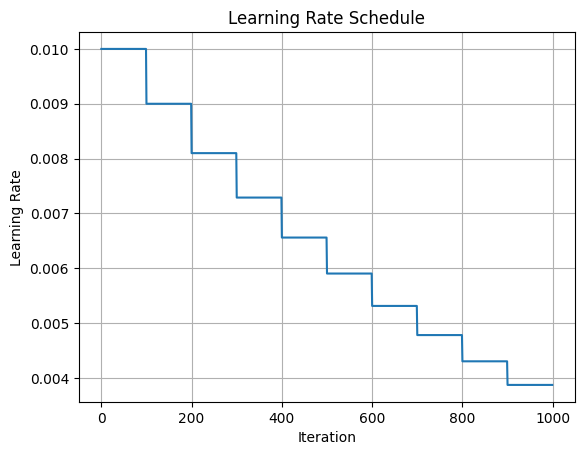

In [5]:
# Simple visualization of the learning rate scheduler
test_scheduler = sched_cls(opt_cls(model_generator().parameters(), lr=step_size), **sched_kwargs)
visualize_scheduler(test_scheduler, iterations)

### Run benchmark

In [6]:
result = benchmark.benchmark(algorithms=algorithms, benchmark_problem=problem, n_trials=n_trials, show_speed=True)

[04/01/26 17:01:03] INFO     No checkpoint manager provided, running benchmark without            ]8;id=161438;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=854815;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#267\267]8;;\
                             checkpointing. Progress cannot be resumed if interrupted.                             

                    INFO     Starting benchmark execution                                         ]8;id=584190;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=119890;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#353\353]8;;\

Output()

[04/01/26 17:05:28] INFO     Benchmark execution complete, thanks for using decent-bench          ]8;id=677488;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py\_benchmark.py]8;;\:]8;id=303879;file:///home/ubuntu/github/decent-bench/decent_bench/benchmark/_benchmark.py#371\371]8;;\

### Compute metrics

In [7]:
metric_result = benchmark.compute_metrics(
    benchmark_result=result,
    table_metrics=table_metrics,
    plot_metrics=plot_metrics,
)

Output()

Output()

### Display metrics

[04/01/26 17:21:39] INFO     Empirical-risk cost functions are in use. Compute counters increment by  ]8;id=916250;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=88406;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#67\67]8;;\
                             the number of samples processed in each method call, which can lead to                
                             large raw counts. Applying scaling factor of 'scale_compute=1.0' to ['nr              
                             gradient calls'] metrics for display.                                                 

                    INFO                                                                              ]8;id=43552;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py\_tables.py]8;;\:]8;id=101457;file:///home/ubuntu/github/decent-bench/decent_bench/metrics/_tables.py#98\98]8;;\
                             +-------------------------+---------------------+---------------------+-              
                             ----------------------+-----------------------+-----------------------+-              
                             ----------------------+                                                               
                             | Metric (statistic)      | DiNNO               | LT-ADMM             |               
                             LT-ADMM-EMA-Optim-F   | LT-ADMM-EMA-Torch-F   | LT-ADMM-EMA-Optim-T   |               
                             LT-ADMM-EMA-Torch-T   |                                                               
                             +=========================+=====================+=====================+=              
                             ======================+=======================+=======================+=              
                             ======================+                                                               
                             | consensus error (min)   | 8.22e-02 ± 0.00e+00 | 1.07e-01 ± 0.00e+00 |               
                             7.58e-02 ± 0.00e+00   | 1.21e+01 ± 0.00e+00   | 1.50e-02 ± 0.00e+00   |               
                             1.24e+01 ± 0.00e+00   |                                                               
                             +-------------------------+---------------------+---------------------+-              
                             ----------------------+-----------------------+-----------------------+-              
                             ----------------------+                                                               
                             | consensus error (avg)   | 2.11e-01 ± 0.00e+00 | 1.86e-01 ± 0.00e+00 |               
                             1.33e-01 ± 0.00e+00   | 1.60e+01 ± 0.00e+00   | 2.32e-02 ± 0.00e+00   |               
                             1.58e+01 ± 0.00e+00   |                                                               
                             +-------------------------+---------------------+---------------------+-              
                             ----------------------+-----------------------+-----------------------+-              
                             ----------------------+                                                               
                             | consensus error (max)   | 4.46e-01 ± 0.00e+00 | 2.74e-01 ± 0.00e+00 |               
                             1.88e-01 ± 0.00e+00   | 1.89e+01 ± 0.00e+00   | 3.13e-02 ± 0.00e+00   |               
                             1.98e+01 ± 0.00e+00   |                                                               
                             +-------------------------+---------------------+---------------------+-              
                             ----------------------+-----------------------+-----------------------+-              
                             ----------------------+                                                               
                             | nr gradient calls (avg) | 6.40e+05 ± 0.00e+00 | 6.40e+05 ± 0.00e+00 |               
                             6.40e+05 ± 0.00e+00   | 0.00e+00 ± 0.00e+00   | 6.40e+05 ± 0.00e+00   |               
                             0.00e+00 ± 0.00e+00   |                                                               
                             +-------------------------+---------------------+---------------------+-              
                             ----------------------+-----------------------+----------------------

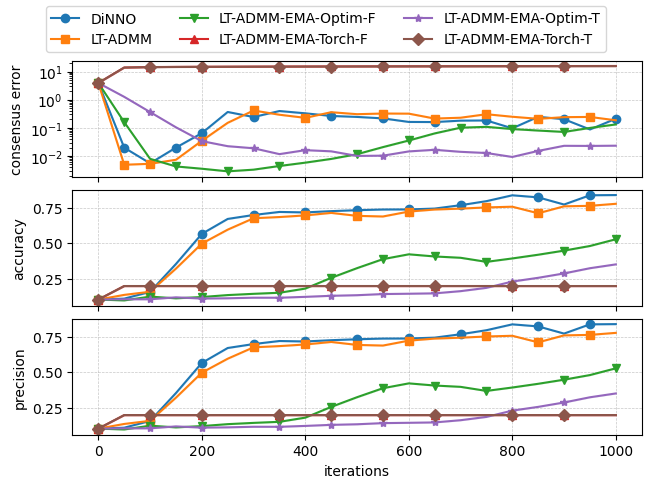

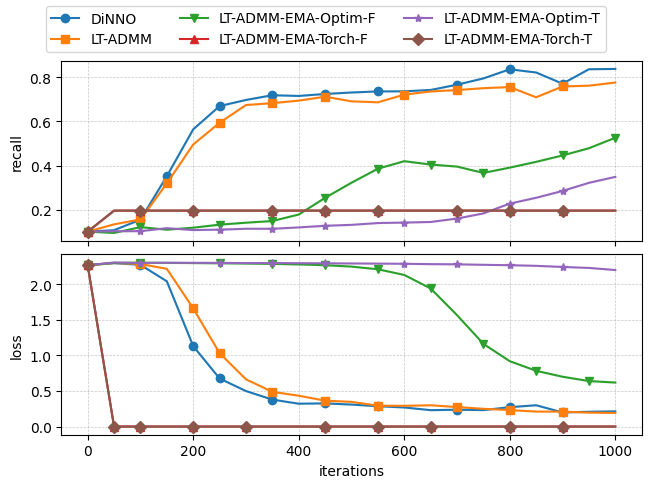

In [8]:
benchmark.display_metrics(metrics_result=metric_result)

### Visualize agents

'Results for DiNNO, 1 trials'

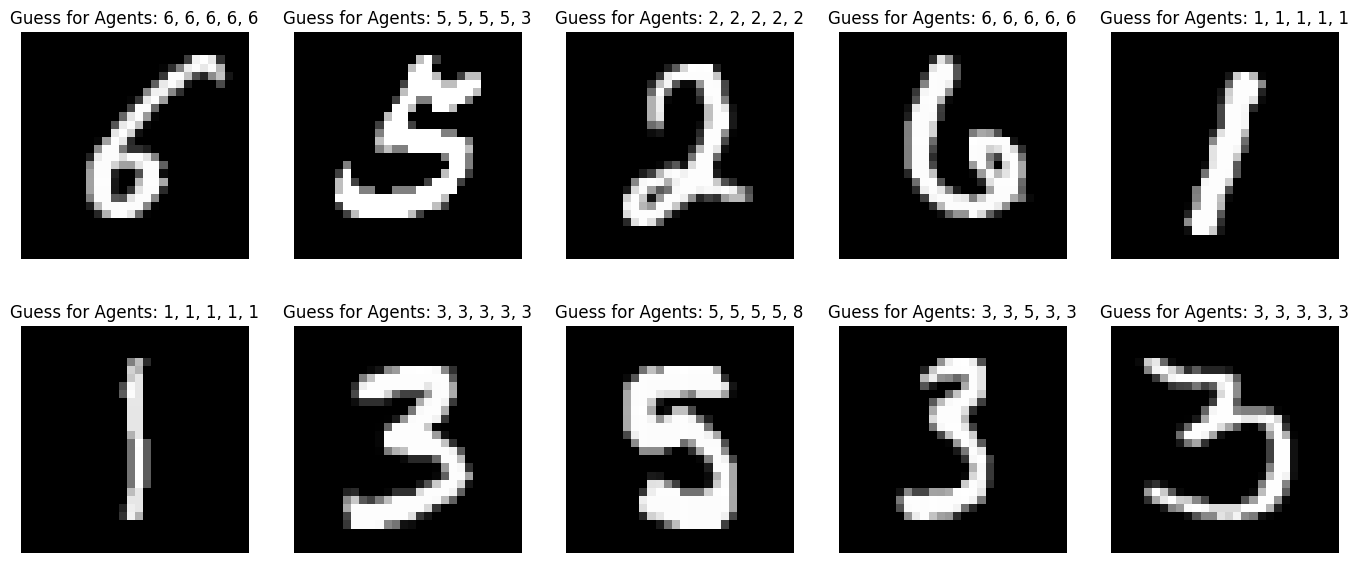

'Results for LT-ADMM, 1 trials'

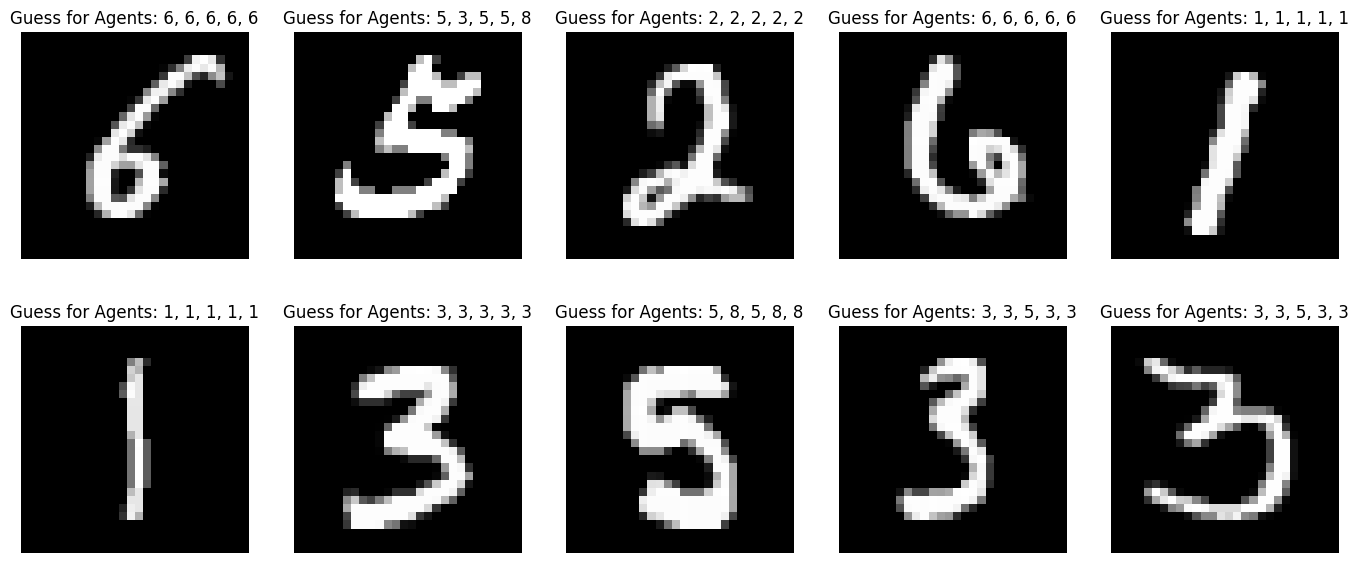

'Results for LT-ADMM-EMA-Optim-F, 1 trials'

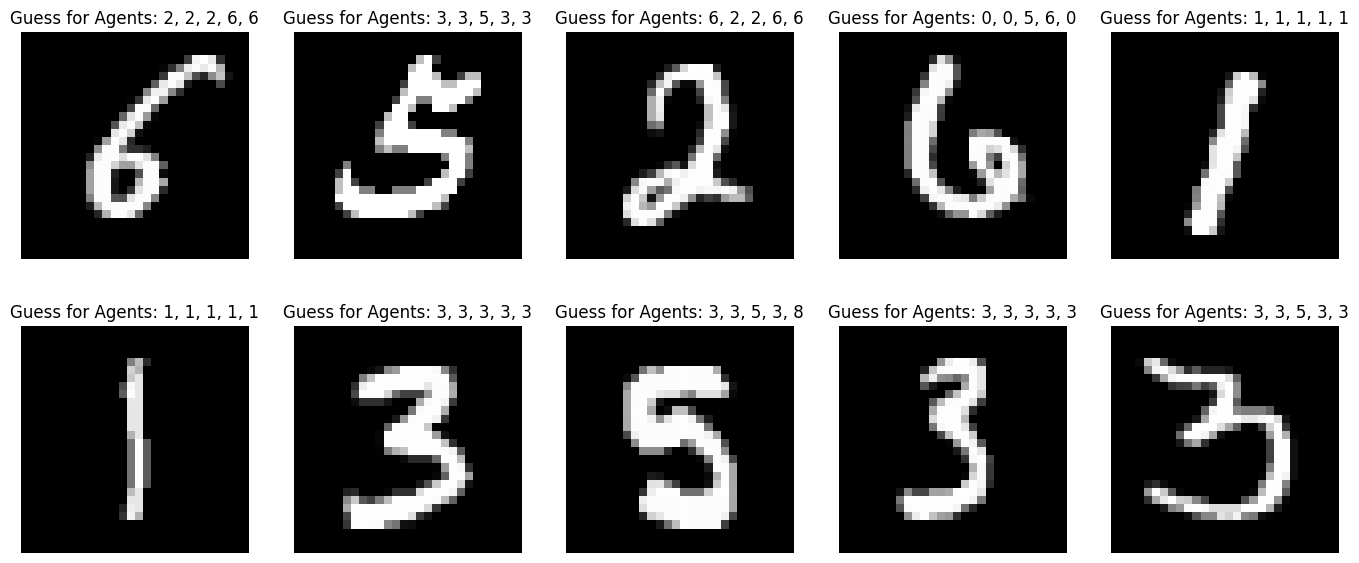

'Results for LT-ADMM-EMA-Torch-F, 1 trials'

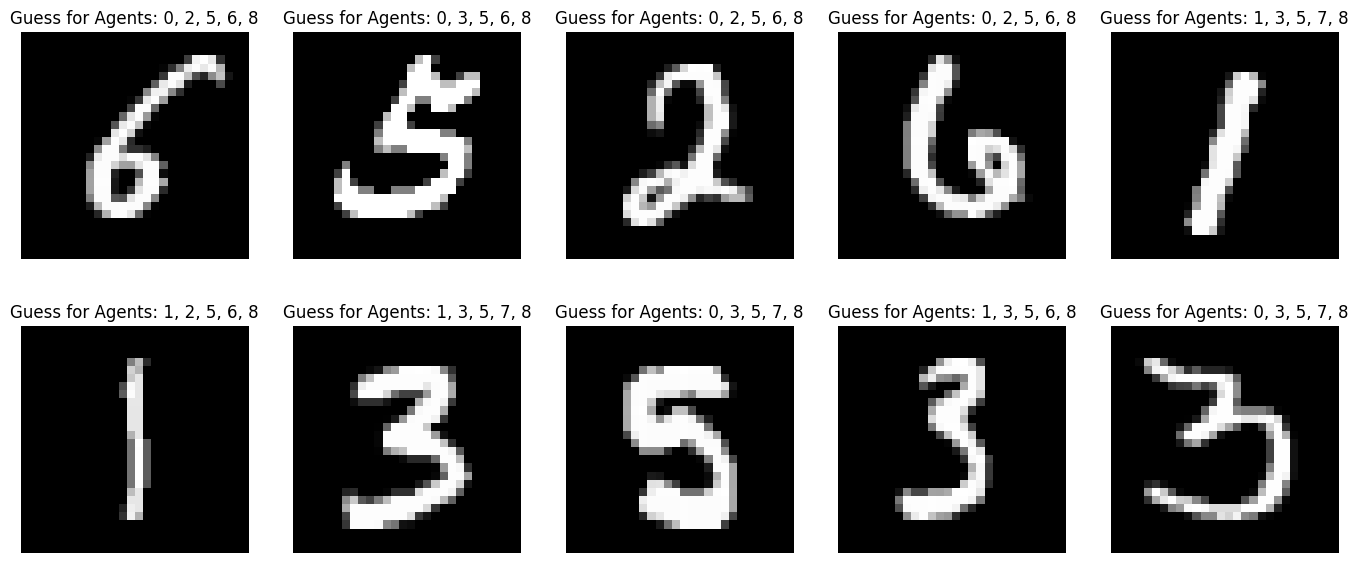

'Results for LT-ADMM-EMA-Optim-T, 1 trials'

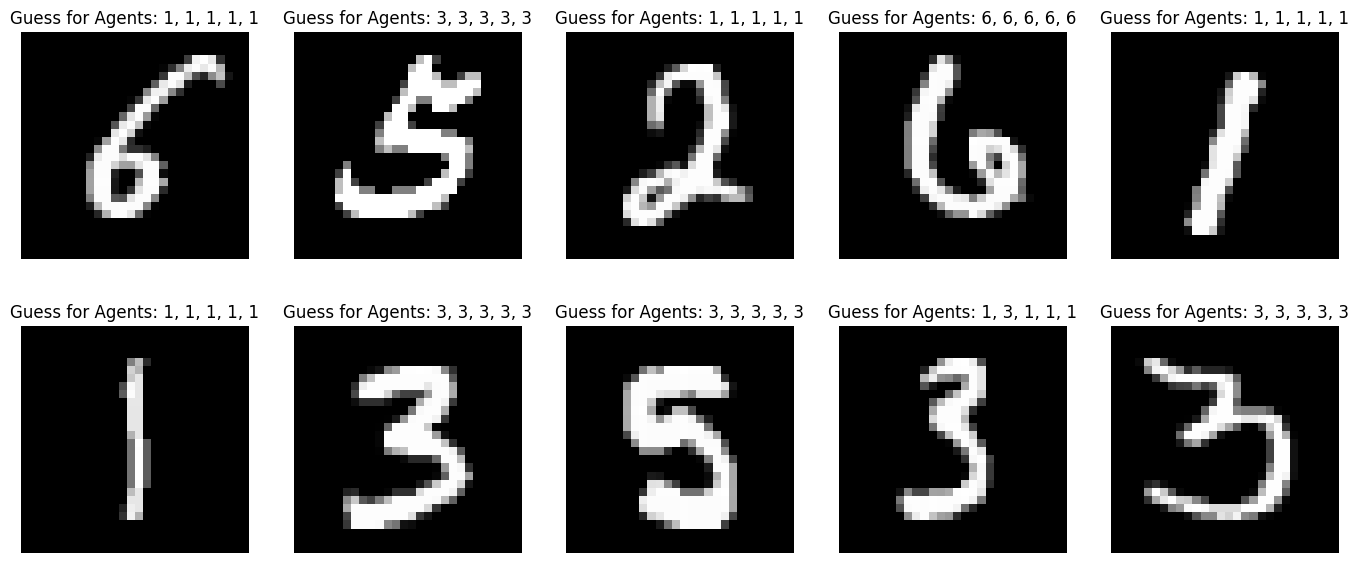

'Results for LT-ADMM-EMA-Torch-T, 1 trials'

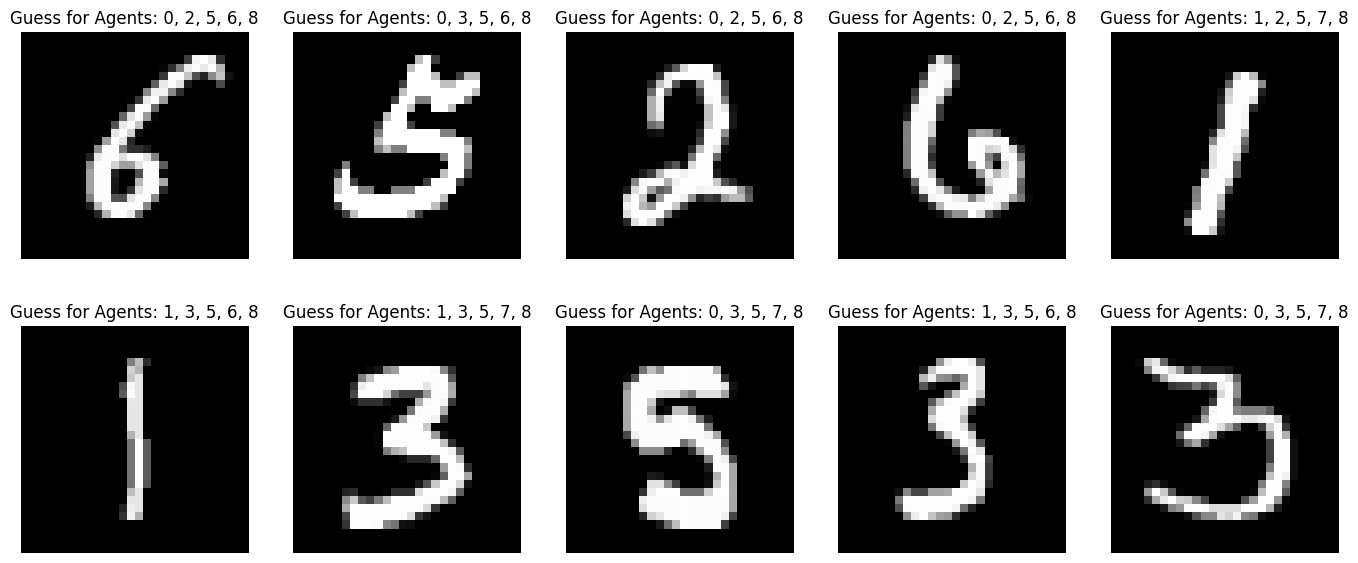

In [9]:
test_loader = DataLoader(test_dataset.get_datapoints(), batch_size=10, shuffle=True)
data_iter = iter(test_loader)
images, labels = next(data_iter)
images, labels = images.to(torch_device), labels.to(torch_device)
for alg, networks in result.states.items():
    display(f"Results for {alg.name}, {len(networks)} trials")
    for n in networks:
        all_agents = n.agents()
        all_preds = [[] for _ in range(len(labels))]
        for agent in all_agents:
            if not isinstance(agent.cost, PyTorchCost):
                raise ValueError("Cost is not a PyTorchCost, cannot compute predictions.")
            preds = agent.cost.predict(agent.x, images)
            for i in range(len(labels)):
                all_preds[i].append(preds[i])

        fig, ax = plt.subplots(2, len(labels) // 2, figsize=(17, 7))
        for i in range(len(labels)):
            row = i // (len(labels) // 2)
            col = i % (len(labels) // 2)
            ax[row, col].imshow(images[i].reshape(28, 28).cpu(), cmap="gray")
            ax[row, col].set_title(f"Guess for Agents: {', '.join(map(str, all_preds[i]))}")
            ax[row, col].axis("off")
        plt.show()

### Centralized solution

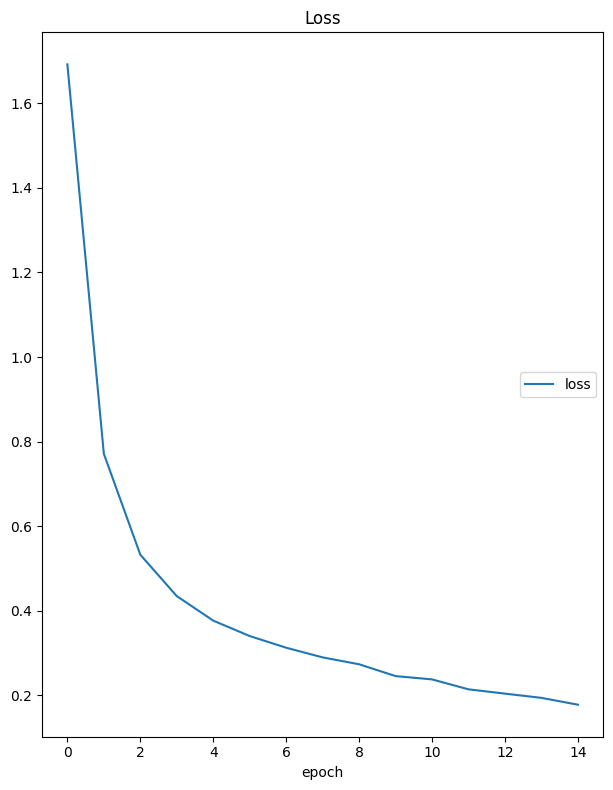

Loss
	loss             	 (min:    0.178, max:    1.692, cur:    0.178)


In [10]:
model = model_generator()
model.to(torch_device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

epochs = 15
criterion = nn.CrossEntropyLoss()
liveloss = PlotLosses()
model.train()
dataloader = DataLoader(train_dataset.get_datapoints(), batch_size=batch_size, shuffle=True, pin_memory=True)
for epoch in range(epochs):
    running_loss = 0.0
    for inputs, targets in dataloader:
        inputs, targets = inputs.to(torch_device), targets.to(torch_device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()

        running_loss += loss.detach()
    epoch_loss = running_loss / len(dataloader)
    liveloss.update({"loss": epoch_loss.item()})
    liveloss.send()

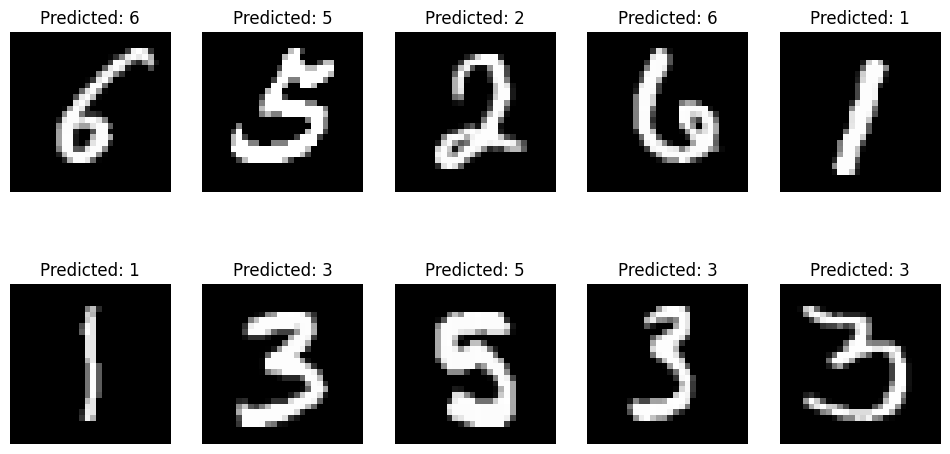

In [11]:
# Visualize a few mnist test samples with predictions
model.eval()
outputs = model(images)
predicted = torch.argmax(outputs, 1)
# Plot images with predicted labels
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    ax.imshow(images[i].cpu().view(28, 28), cmap="gray")
    ax.set_title(f"Predicted: {predicted[i].item()}")
    ax.axis("off")
plt.show()

In [2]:
import torch
from decent_bench.agents import Agent
import decent_bench.utils.interoperability as iop
from decent_bench.costs import ZeroCost

a = torch.tensor([1, 2, 3])
agent = Agent(0, ZeroCost((3,)), None)
agent.initialize(x=a)


x_before_local = agent.x
x_k = iop.copy(agent.x)

for i in range(3):
    x_k -= 1
agent.x = x_k

display(f"x before local steps: {x_before_local}")
display(f"x after local steps: {agent.x}")

'x before local steps: tensor([1, 2, 3])'

'x after local steps: tensor([-2, -1,  0])'